# Probabilistic Shielding MiniPacman

This tutorial turns `masa/examples/prob_shield_example.py` into an inspection-first notebook. Instead of training PPO, we build MiniPacman, apply the `pctl` constraint, wrap it with `ProbShieldWrapperDisc`, and inspect the augmented observations, safety bounds, successor dynamics, and projected safe actions.

The matching static docs page is at `docs/Tutorials/Shielding/Probabilistic Shielding MiniPacman.md`.

## CPU-first setup

Keep the notebook portable and quiet before importing MASA/JAX modules.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

'2'

## Imports

MiniPacman exposes a discrete state space and transition model, which is exactly what the discrete probabilistic shield needs.

In [2]:
import numpy as np
from IPython.display import Markdown, SVG, display

from masa.common.utils import make_env
from masa.envs.tabular.mini_pacman import REVERSE_STATE_MAP, cost_fn, label_fn
from masa.prob_shield.prob_shield_wrapper_v1 import ProbShieldWrapperDisc
from helpers.probabilistic_shielding import render_simplex_projection_svg


Computing successor states and probabilities ... 


100%|█████████████████████████████████████████████████████████████████████████████| 9248/9248 [00:03<00:00, 2399.02it/s]


## Build the PCTL-constrained MiniPacman environment

The base environment is the same one used in the script example. `make_env` applies MASA's normal wrapper stack, and the `pctl` constraint tracks unsafe probability through the MiniPacman `cost_fn`.

In [3]:
def make_minipacman_pctl_env(max_episode_steps=100):
    return make_env(
        "MiniPacman",
        "PCTL",
        max_episode_steps,
        label_fn=label_fn,
        constraint_kwargs={"cost_fn": cost_fn, "alpha": 0.01},
    )


base_env = make_minipacman_pctl_env()
print("base observation_space:", base_env.observation_space)
print("base action_space:", base_env.action_space)
base_env.close()

base observation_space: Discrete(9248)
base action_space: Discrete(5)


## Add the probabilistic shield

`ProbShieldWrapperDisc` computes interval safety bounds from the known transition model, augments observations with the current safety budget, and projects augmented actions onto safe action distributions.

In [4]:
def make_shielded_minipacman_env():
    env = make_minipacman_pctl_env()
    return ProbShieldWrapperDisc(
        env,
        init_safety_bound=0.01,
        theta=1e-12,
        max_vi_steps=2_000,
        granularity=10,
    )


shielded_env = make_shielded_minipacman_env()

print("shielded observation_space:", shielded_env.observation_space)
print("shielded action_space:", shielded_env.action_space)
print("max_successors:", shielded_env.max_successors)
print("successor_states_matrix shape:", shielded_env.successor_states_matrix.shape)
print("probabilities shape:", shielded_env.probabilities.shape)
print("safety_lb shape:", shielded_env.safety_lb.shape)
print("safety_lb range:", float(np.min(shielded_env.safety_lb)), float(np.max(shielded_env.safety_lb)))

Calculating the maximum number of successor states ...
Calculated maximum number of successor states [12] ...
Building successor state matrix and probabilities ...
Computing almost sure safe set ...
Initializing value iteration ...
Completed value iteration ...
Initial state lower bound: 0.0
shielded observation_space: Dict('orig_obs': Discrete(9248), 'safety_bound': Box(0.0, 1.0, (1,), float32))
shielded action_space: MultiDiscrete([ 5  5 11 11 11 11 11 11 11 11 11 11 11 11])
max_successors: 12
successor_states_matrix shape: (12, 9248)
probabilities shape: (12, 9248, 5)
safety_lb shape: (9248,)
safety_lb range: 0.0 1.0


## Inspect the augmented reset

The original discrete MiniPacman state is still available as `orig_obs`. The shield adds `safety_bound`, the remaining probability budget that future projected actions must preserve.

In [5]:
obs, info = shielded_env.reset(seed=0)

print("obs:", obs)
print("orig_obs:", obs["orig_obs"])
print("safety_bound:", obs["safety_bound"])
print("labels:", info["labels"])
print("constraint:", info["constraint"])

assert "orig_obs" in obs
assert "safety_bound" in obs
assert obs["safety_bound"] == 0.01

obs: {'orig_obs': 1335, 'safety_bound': 0.01}
orig_obs: 1335
safety_bound: 0.01
labels: set()
constraint: {'type': 'pctl', 'step': {'cost': 0.0, 'violation': 0.0}}


## Small inspection helpers

These helpers expose the state of the shield for this tutorial. `_parse_act` and `_project_act` are internal methods; use them here as teaching probes, not as a stable public API.

In [6]:
ACTION_NAMES = {
    0: "right",
    1: "down",
    2: "left",
    3: "up",
    4: "stay",
}


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    return "\n".join([header, divider, *body])


def decode_minipacman_state(state):
    agent_y, agent_x, agent_direction, ghost_y, ghost_x, ghost_direction, food = REVERSE_STATE_MAP[int(state)]
    return {
        "state": int(state),
        "agent": (agent_x, agent_y),
        "agent_direction": int(agent_direction),
        "ghost": (ghost_x, ghost_y),
        "ghost_direction": int(ghost_direction),
        "food_available": bool(food),
        "labels": ", ".join(sorted(label_fn(int(state)))) or "-",
        "safety_lb": round(float(shielded_env.safety_lb[int(state)]), 4),
    }


def current_successor_rows(env):
    current = env._current_obs
    successors = env.successor_states_matrix[:, current]
    keep = successors >= 0
    rows = []
    for slot, successor in enumerate(successors[keep]):
        row = decode_minipacman_state(successor)
        row["slot"] = slot
        rows.append(row)
    return rows


def current_probability_rows(env):
    current = env._current_obs
    successors = env.successor_states_matrix[:, current]
    keep = successors >= 0
    probs = env.probabilities[keep, current, :]
    rows = []
    for slot, successor in enumerate(successors[keep]):
        row = {"slot": slot, "successor": int(successor)}
        for action, name in ACTION_NAMES.items():
            row[name] = round(float(probs[slot, action]), 3)
        rows.append(row)
    return rows


def make_augmented_action(primary_action, fallback_action=None, beta_level=0):
    fallback_action = primary_action if fallback_action is None else fallback_action
    return np.array(
        [primary_action, fallback_action] + [beta_level] * shielded_env.max_successors,
        dtype=int,
    )


def project_candidate_action(env, action):
    i, j, betas = env._parse_act(action)
    safe_actions, bounds, proj_penalty, margin_penalty = env._project_act(i, j, betas)
    return {
        "primary": ACTION_NAMES[int(i)],
        "fallback": ACTION_NAMES[int(j)],
        "beta_level": int(action[2]) if len(action) > 2 else None,
        "safe_actions": np.round(safe_actions, 3).tolist(),
        "bounds": np.round(bounds[: np.count_nonzero(env.successor_states_matrix[:, env._current_obs] >= 0)], 4).tolist(),
        "proj_penalty": round(float(proj_penalty), 4),
        "margin_penalty": round(float(margin_penalty), 4),
    }

## Inspect successor dynamics and lower bounds

At the reset state, MiniPacman has two stochastic successor states because the ghost can move stochastically. The shield combines these probabilities with the safety lower bounds.

In [7]:
current_state = decode_minipacman_state(shielded_env._current_obs)
display(Markdown("### Current state\n" + markdown_table([current_state], list(current_state.keys()))))

successor_columns = ["slot", "state", "agent", "ghost", "food_available", "labels", "safety_lb"]
display(Markdown("### Reachable successors\n" + markdown_table(current_successor_rows(shielded_env), successor_columns)))

probability_columns = ["slot", "successor", "right", "down", "left", "up", "stay"]
display(Markdown("### Transition probabilities by action\n" + markdown_table(current_probability_rows(shielded_env), probability_columns)))

### Current state
| state | agent | agent_direction | ghost | ghost_direction | food_available | labels | safety_lb |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1335 | (4, 1) | 1 | (3, 5) | 1 | True | - | 0.0 |

### Reachable successors
| slot | state | agent | ghost | food_available | labels | safety_lb |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 1607 | (5, 1) | (3, 5) | True | - | 0.0 |
| 1 | 1611 | (5, 1) | (4, 5) | True | - | 0.0 |

### Transition probabilities by action
| slot | successor | right | down | left | up | stay |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 1607 | 0.6 | 0.6 | 0.6 | 0.6 | 0.6 |
| 1 | 1611 | 0.4 | 0.4 | 0.4 | 0.4 | 0.4 |

## Projection geometry on a toy MDP

Before looking at MiniPacman-specific projected actions, it helps to see the geometry on a tiny exact MDP. Sound VI gives `beta(safe)=0`, `beta(unsafe)=1`, and action risks `0.02`, `0.08`, and `0.20` at `s0`. With budget `q=0.10`, the green region is the safe part of the probability simplex, while the red region is clipped away because it exceeds the safety half-space.


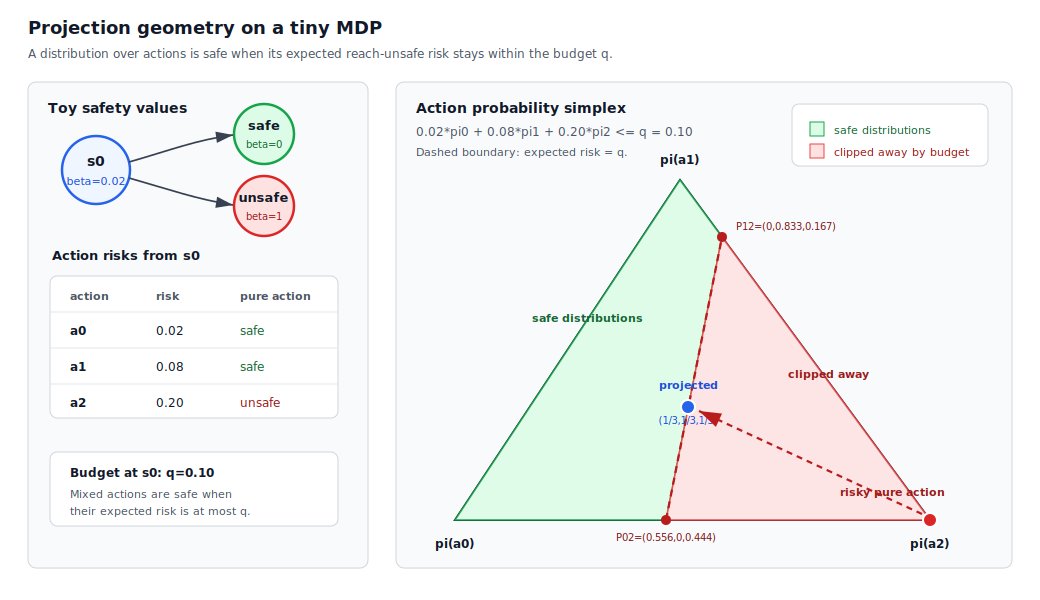

In [8]:
display(SVG(render_simplex_projection_svg()))


## Inspect projected safe actions

A shielded discrete action is a `MultiDiscrete` vector. The first two entries select candidate MiniPacman actions, and the remaining entries encode candidate successor safety-bound levels from `0` to `granularity`.

In [9]:
candidate_actions = [
    make_augmented_action(0, beta_level=0),
    make_augmented_action(1, beta_level=0),
    make_augmented_action(4, beta_level=0),
    make_augmented_action(0, beta_level=shielded_env.granularity),
]

projection_rows = [project_candidate_action(shielded_env, action) for action in candidate_actions]
projection_columns = ["primary", "fallback", "beta_level", "safe_actions", "bounds", "proj_penalty", "margin_penalty"]
display(Markdown(markdown_table(projection_rows, projection_columns)))

| primary | fallback | beta_level | safe_actions | bounds | proj_penalty | margin_penalty |
| --- | --- | --- | --- | --- | --- | --- |
| right | right | 0 | [1.0, 0.0, 0.0, 0.0, 0.0] | [0.01, 0.01] | 0.01 | 18.4306 |
| down | down | 0 | [0.0, 1.0, 0.0, 0.0, 0.0] | [0.01, 0.01] | 0.01 | 18.4306 |
| stay | stay | 0 | [0.0, 0.0, 0.0, 0.0, 1.0] | [0.01, 0.01] | 0.01 | 18.4306 |
| right | right | 10 | [1.0, 0.0, 0.0, 0.0, 0.0] | [0.01, 0.01] | 0.99 | 18.4306 |

## Step once through the shield

The wrapper samples an original MiniPacman action from the projected safe action distribution, steps the wrapped environment, and updates the remaining `safety_bound` for the reached successor.

In [10]:
step_action = make_augmented_action(0, beta_level=0)
next_obs, reward, terminated, truncated, step_info = shielded_env.step(step_action)

print("next_obs:", next_obs)
print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
print("constraint:", step_info["constraint"])
print("margin_penalty:", step_info["margin_penalty"])
print("proj_penalty:", step_info["proj_penalty"])

assert "orig_obs" in next_obs
assert "safety_bound" in next_obs
assert "constraint" in step_info
assert "margin_penalty" in step_info
assert "proj_penalty" in step_info
assert float(next_obs["safety_bound"]) <= 1.0

next_obs: {'orig_obs': 1607, 'safety_bound': 0.01}
reward: 0.0
terminated: False
truncated: False
constraint: {'type': 'pctl', 'step': {'cost': 0.0, 'violation': 0.0}, 'episode': {'cum_unsafe': 0.0, 'satisfied': 1.0}}
margin_penalty: 18.430629623981083
proj_penalty: 0.01


## Where PPO would fit

The script example trains PPO on the shielded environment. This notebook stops before training so it can stay fast and focused. In a full run, PPO would receive `shielded_env` as its training environment and a separate shielded eval env built with the same factory.

In [11]:
PPO_TRAINING_SKETCH = {
    "env": "make_shielded_minipacman_env()",
    "eval_env": "make_shielded_minipacman_env()",
    "num_frames": "large training run, intentionally omitted here",
}

PPO_TRAINING_SKETCH

{'env': 'make_shielded_minipacman_env()',
 'eval_env': 'make_shielded_minipacman_env()',
 'num_frames': 'large training run, intentionally omitted here'}

## Cleanup

Close the shielded environment when finished.

In [12]:
shielded_env.close()